In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [3]:
df=pd.read_excel('datasets/nyeri.xlsx')

In [4]:
selected_columns=df.select_dtypes(include=['object','string']).columns
df[selected_columns]=df[selected_columns].apply(
    lambda x:x.str.strip().str.upper()
)

In [5]:
df['student_gender']=df['student_gender'].replace({
    'F':'FEMALE',
    'M':'MALE',
    'FE4MALE':'FEMALE'
})

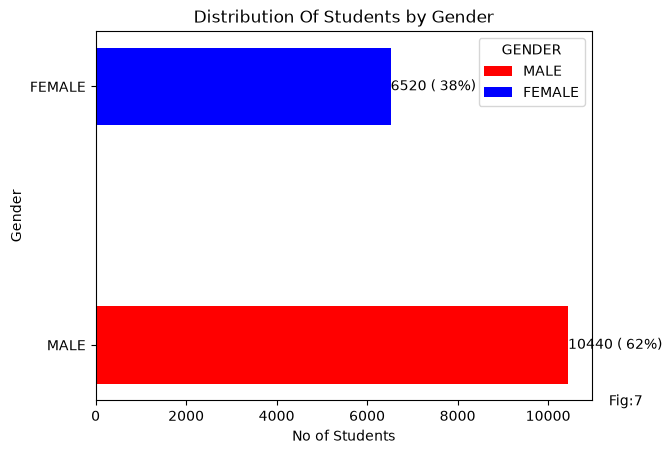

In [ ]:
gender_count=df['student_gender'].value_counts()
plt.barh(gender_count.index,gender_count.values,color=['red','blue'],height=0.3)
plt.title('Distribution Of Students by Gender')
plt.xlabel('No of Students')
plt.ylabel('Gender')

colors=[
    Patch(facecolor='red',label='MALE'),
    Patch(facecolor='blue',label='FEMALE')
]

plt.legend(
    handles=colors,
    title='GENDER',
    loc='upper right'
)

plt.figtext(0.98,0.1,'Fig:7', ha='right')

for i, value in enumerate(gender_count.values):
    percentage=(value/gender_count.sum())*100
    plt.text(
         value,
         i,
         f'{value} ({percentage: .0f}%)',
         va='center'
    )

plt.ylim(-0.5, len(gender_count) - 0.5)
plt.xlim(0, gender_count.max() * 1.15)

plt.show()